In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM,Dense,Dropout



In [99]:
df=pd.read_csv("goog.csv")

In [100]:
df.head()

,Date,Open,High,Low,Close,Volume
0,12/19/2016,790.219971,797.659973,786.270020,794.200012,1225900
1,12/20/2016,796.760010,798.650024,793.270020,796.419983,925100
2,12/21/2016,795.840027,796.676025,787.099976,794.559998,1208700
3,12/22/2016,792.359985,793.320007,788.580017,791.260010,969100
4,12/23/2016,790.900024,792.739990,787.280029,789.909973,623400


In [101]:
df.shape

(61, 6)

In [102]:
df.info

<bound method DataFrame.info of           Date        Open        High         Low       Close   Volume
0   12/19/2016  790.219971  797.659973  786.270020  794.200012  1225900
1   12/20/2016  796.760010  798.650024  793.270020  796.419983   925100
2   12/21/2016  795.840027  796.676025  787.099976  794.559998  1208700
3   12/22/2016  792.359985  793.320007  788.580017  791.260010   969100
4   12/23/2016  790.900024  792.739990  787.280029  789.909973   623400
..         ...         ...         ...         ...         ...      ...
56   3/13/2017  844.000000  848.684998  843.250000  845.539978  1149500
57   3/14/2017  843.640015  847.239990  840.799988  845.619995   779900
58   3/15/2017  847.590027  848.630005  840.770020  847.200012  1379600
59   3/16/2017  849.030029  850.849976  846.130005  848.780029   970400
60   3/17/2017  851.609985  853.400024  847.109985  852.119995  1712300

[61 rows x 6 columns]>

In [103]:
df.isnull().sum()

Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

In [104]:
close_data=df[['Close']]

close_data.head()

,Close
0,794.200012
1,796.419983
2,794.559998
3,791.260010
4,789.909973


In [105]:
scaler=MinMaxScaler()
scaled_data=scaler.fit_transform(close_data)

In [106]:
X=[]
y=[]

time_step=5

for i in range(time_step,len(scaled_data)):
    X.append(scaled_data[i-time_step:i,0])
    y.append(scaled_data[i,0])
    

In [107]:
X=np.array(X)
y=np.array(y)


In [108]:
len(X)

56

In [109]:
len(y)

56

In [110]:
X.shape

(56, 5)

In [111]:
X=X.reshape(X.shape[0],X.shape[1],1)

In [112]:
X.shape

(56, 5, 1)

In [113]:
split=int(0.8*len(X))

In [114]:
X_train=X[:split]
y_train=y[:split]

X_test=X[split:]
y_test=y[split:]

In [115]:
print("\nTraining Samples:", len(X_train))
print("Testing Samples:", len(X_test))



Training Samples: 44
Testing Samples: 12


In [116]:
model=Sequential()

model.add(LSTM(units=50,return_sequences=True,input_shape=(X_train.shape[1],1)))

C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [117]:
model.add(Dropout(0.2))
model.add(LSTM(units=50))
model.add(Dropout(0.2))


In [118]:
model.add(Dense(25,activation='relu'))
model.add(Dense(1))

In [119]:
model.compile(optimizer='adam',loss='mean_squared_error')

In [120]:
history=model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=1,
    validation_data=(X_test, y_test),
    shuffle=False,
    verbose=1
)

Epoch 1/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - loss: 0.0557 - val_loss: 0.0100
Epoch 2/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0499 - val_loss: 0.0080
Epoch 3/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0483 - val_loss: 0.0104
Epoch 4/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0416 - val_loss: 0.0068
Epoch 5/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0381 - val_loss: 0.0041
Epoch 6/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0490 - val_loss: 0.0037
Epoch 7/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0429 - val_loss: 0.0041
Epoch 8/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0378 - val_loss: 0.0099
Epoch 9/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0347 - val_loss: 0.0103
Epoch 10/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0331 - val_loss: 0.0072
Epoch 11/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0367 - val_loss: 0.0085
Epoch 12/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0325 - 

In [121]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                        │ (None, 5, 50)               │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 5, 50)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_5 (LSTM)                        │ (None, 50)                  │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 25)                  │           1,275 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 95,705 (373.85 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 63,804 (249.24 KB)

In [122]:
predicted_price=model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 520ms/step


In [123]:
print(predicted_price)

[[0.7028657 ]
 [0.7083647 ]
 [0.70755243]
 [0.7011745 ]
 [0.7101031 ]
 [0.72328544]
 [0.74705535]
 [0.7796711 ]
 [0.81164527]
 [0.83249015]
 [0.8491643 ]
 [0.8639145 ]]


In [124]:
predicted_price=scaler.inverse_transform(predicted_price)

In [125]:
print(predicted_price)

[[828.26013]
 [828.70166]
 [828.6364 ]
 [828.1243 ]
 [828.84125]
 [829.89984]
 [831.80853]
 [834.42755]
 [836.9951 ]
 [838.66895]
 [840.0079 ]
 [841.1923 ]]


In [126]:
print(y_test)

[0.73237866 0.7130762  0.69688705 0.74831849 0.79140719 0.8326276
 0.88953927 0.91805706 0.91905354 0.93872997 0.95840639 1.        ]


In [127]:
y_test=scaler.inverse_transform(y_test.reshape(-1,1))

In [128]:
mse = mean_squared_error(
    y_test,
    predicted_price
)

In [129]:
print(mse)

61.5387607249495


In [130]:
print("RMSE:",np.sqrt(mse))

RMSE: 7.8446644749759376


Text(0, 0.5, 'Stock Price')

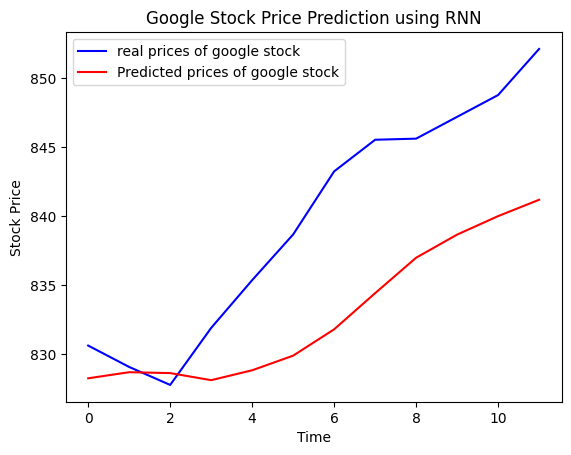

In [131]:
plt.plot(y_test,color='blue',label='real prices of google stock')
plt.plot(predicted_price,color='red',label='Predicted prices of google stock')
plt.legend()
plt.title("Google Stock Price Prediction using RNN")

plt.xlabel("Time")
plt.ylabel("Stock Price")

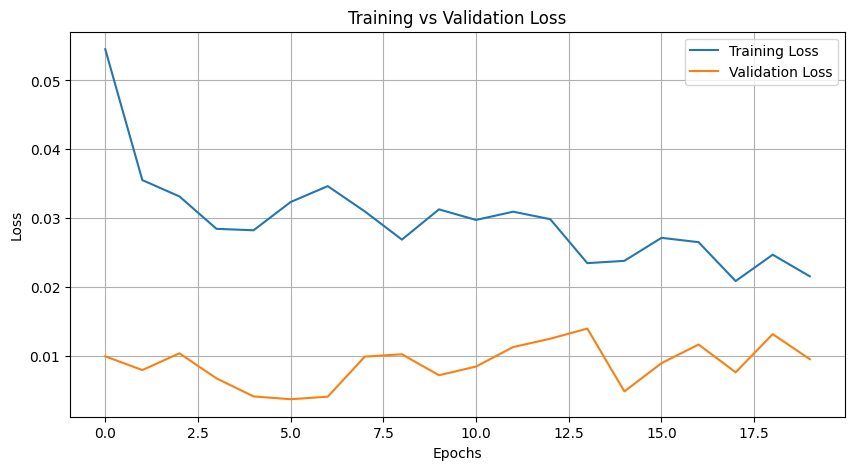

In [132]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'],
         label='Training Loss')

plt.plot(history.history['val_loss'],
         label='Validation Loss')

plt.title("Training vs Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

In [133]:
last_days = scaled_data[-time_step:]

last_days = last_days.reshape(1,time_step,1)

next_day = model.predict(last_days)

next_day_price = scaler.inverse_transform(next_day)

print("\nPredicted Next Day Google Stock Price:")

print(next_day_price)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 650ms/step

Predicted Next Day Google Stock Price:
[[842.69574]]


Dataset Shape: (61, 6)
         Date        Open        High         Low       Close   Volume
0  12/19/2016  790.219971  797.659973  786.270020  794.200012  1225900
1  12/20/2016  796.760010  798.650024  793.270020  796.419983   925100
2  12/21/2016  795.840027  796.676025  787.099976  794.559998  1208700
3  12/22/2016  792.359985  793.320007  788.580017  791.260010   969100
4  12/23/2016  790.900024  792.739990  787.280029  789.909973   623400

Total Sequences: 56
X Shape: (56, 5, 1)
y Shape: (56,)

Training Samples: 44
Testing Samples: 12


C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                        │ (None, 5, 50)               │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 5, 50)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_7 (LSTM)                        │ (None, 50)                  │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 25)                  │           1,275 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.0544 - val_loss: 0.0090
Epoch 2/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0424 - val_loss: 0.0043
Epoch 3/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0586 - val_loss: 0.0062
Epoch 4/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0465 - val_loss: 0.0085
Epoch 5/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0393 - val_loss: 0.0037
Epoch 6/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0407 - val_loss: 0.0126
Epoch 7/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0377 - val_loss: 0.0044
Epoch 8/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0366 - val_loss: 0.0108
Epoch 9/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0345 - val_loss: 0.0180
Epoch 10/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0326 - val_loss: 0.0126
Epoch 11/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0301 - val_loss: 0.0090
Epoch 12/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0305 - val

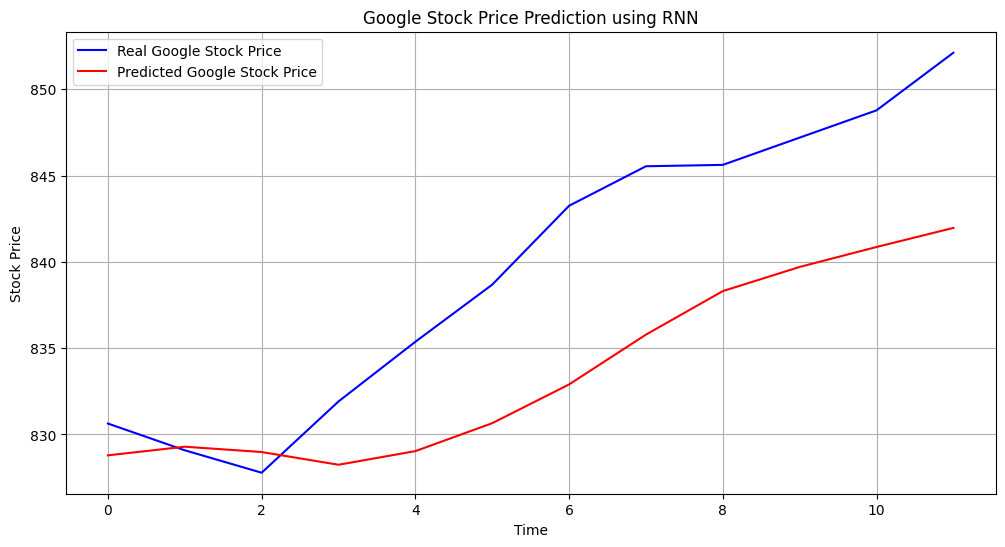

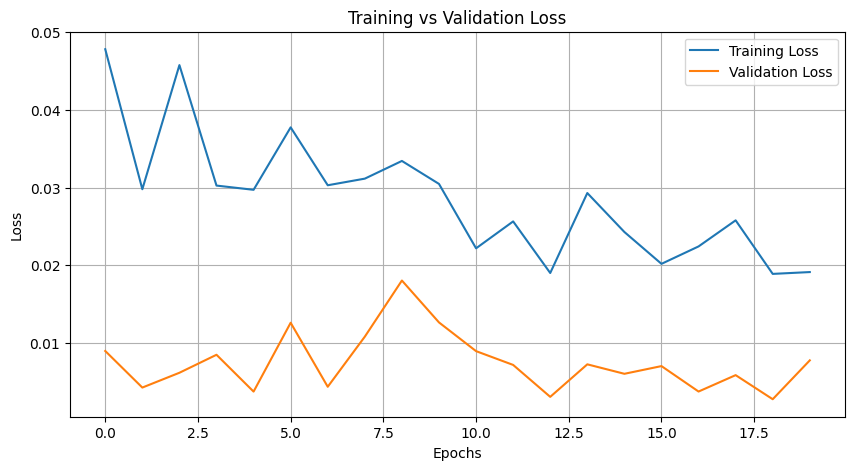

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 496ms/step

Predicted Next Day Google Stock Price:
[[843.6506]]


In [134]:
# =========================================================
# Google Stock Price Prediction using RNN (LSTM)
# FINAL WORKING VERSION
# =========================================================

# =========================================================
# Import Libraries
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# =========================================================
# Load Dataset
# =========================================================

dataset = pd.read_csv("goog.csv")

print("Dataset Shape:", dataset.shape)

print(dataset.head())

# =========================================================
# Select Close Column
# =========================================================

data = dataset[['Close']]

# =========================================================
# Normalize Data
# =========================================================

scaler = MinMaxScaler(feature_range=(0,1))

scaled_data = scaler.fit_transform(data)

# =========================================================
# Create Sequences
# =========================================================

X = []
y = []

# SMALL VALUE because dataset is small
time_step = 5

for i in range(time_step, len(scaled_data)):
    
    X.append(scaled_data[i-time_step:i, 0])
    y.append(scaled_data[i, 0])

# Convert into NumPy Arrays
X = np.array(X)
y = np.array(y)

# =========================================================
# Check Data
# =========================================================

print("\nTotal Sequences:", len(X))

# =========================================================
# Reshape for RNN
# =========================================================

X = X.reshape((X.shape[0], X.shape[1], 1))

print("X Shape:", X.shape)
print("y Shape:", y.shape)

# =========================================================
# Split Data
# =========================================================

split = int(0.8 * len(X))

X_train = X[:split]
y_train = y[:split]

X_test = X[split:]
y_test = y[split:]

print("\nTraining Samples:", len(X_train))
print("Testing Samples:", len(X_test))

# =========================================================
# Build RNN Model
# =========================================================

model = Sequential()

# First LSTM Layer
model.add(LSTM(
    units=50,
    return_sequences=True,
    input_shape=(X_train.shape[1],1)
))

model.add(Dropout(0.2))

# Second LSTM Layer
model.add(LSTM(units=50))

model.add(Dropout(0.2))

# Dense Layers
model.add(Dense(25, activation='relu'))

model.add(Dense(1))

# =========================================================
# Compile Model
# =========================================================

model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

# =========================================================
# Model Summary
# =========================================================

model.summary()

# =========================================================
# Train Model
# =========================================================

history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=1,
    validation_data=(X_test, y_test),
    shuffle=False,
    verbose=1
)

# =========================================================
# Predict
# =========================================================

predicted_prices = model.predict(X_test)

# Convert back to original values
predicted_prices = scaler.inverse_transform(predicted_prices)

real_prices = scaler.inverse_transform(
    y_test.reshape(-1,1)
)

# =========================================================
# RMSE
# =========================================================

mse = mean_squared_error(
    real_prices,
    predicted_prices
)

rmse = np.sqrt(mse)

print("\nRMSE:", rmse)

# =========================================================
# Plot Prediction Graph
# =========================================================

plt.figure(figsize=(12,6))

plt.plot(
    real_prices,
    color='blue',
    label='Real Google Stock Price'
)

plt.plot(
    predicted_prices,
    color='red',
    label='Predicted Google Stock Price'
)

plt.title("Google Stock Price Prediction using RNN")

plt.xlabel("Time")
plt.ylabel("Stock Price")

plt.legend()

plt.grid(True)

plt.show()

# =========================================================
# Plot Loss Graph
# =========================================================

plt.figure(figsize=(10,5))

plt.plot(history.history['loss'],
         label='Training Loss')

plt.plot(history.history['val_loss'],
         label='Validation Loss')

plt.title("Training vs Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

# =========================================================
# Predict Next Day Price
# =========================================================

last_days = scaled_data[-time_step:]

last_days = last_days.reshape(1,time_step,1)

next_day = model.predict(last_days)

next_day_price = scaler.inverse_transform(next_day)

print("\nPredicted Next Day Google Stock Price:")

print(next_day_price)